In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#for reproductibility
np.random.seed(0)

In [ ]:
#dogs have higher ear flappiness and lower whisker length
dogs_whisker_length=np.random.normal(loc=5,scale=1,size=10)
dogs_ear_flappiness_index=np.random.normal(loc=8,scale=1,size=10)

In [ ]:
dogs_whisker_length


array([6.76405235, 5.40015721, 5.97873798, 7.2408932 , 6.86755799,
       4.02272212, 5.95008842, 4.84864279, 4.89678115, 5.4105985 ])

In [ ]:
dogs_ear_flappiness_index

array([8.14404357, 9.45427351, 8.76103773, 8.12167502, 8.44386323,
       8.33367433, 9.49407907, 7.79484174, 8.3130677 , 7.14590426])

In [ ]:
cats_whisker_length=np.random.normal(loc=8,scale=1,size=10)
cats_ear_flappiness_index=np.random.normal(loc=5,scale=1,size=10)

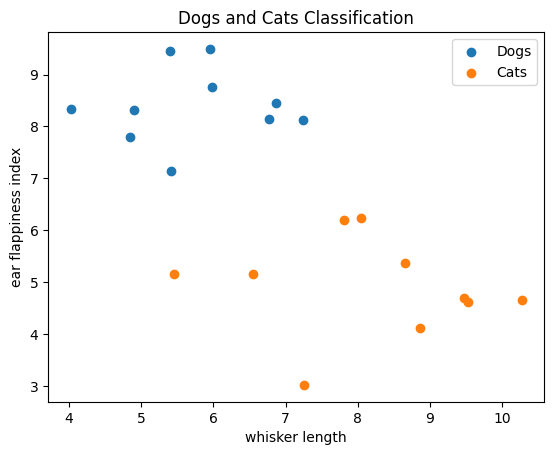

In [ ]:
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index,label="Dogs")
plt.scatter(cats_whisker_length,cats_ear_flappiness_index,label="Cats")
plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dogs and Cats Classification")
plt.legend()
plt.show()

In [ ]:


def random_linear_classifier(data_dogs, data_cats, k, d):
    # d = number of features (dimension)
    
    best_error = float("inf")
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        # Generate random parameters
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        # Compute classification error
        error = compute_error(data_dogs, data_cats, theta, theta0)

        # Keep the best classifier found so far
        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta0, best_theta

In [ ]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0

    for x_dogs in data_dogs:
        if np.dot(theta, x_dogs) + theta0 <= 0:
            error += 1

    for x_cats in data_cats:
        if np.dot(theta, x_cats) + theta0 > 0:
            error += 1

    return error

In [ ]:
dogs_data=np.vstack((dogs_ear_flappiness_index,dogs_whisker_length)).T
cats_data=np.vstack((cats_ear_flappiness_index,cats_whisker_length)).T

In [ ]:
dogs_data


array([[8.14404357, 6.76405235],
       [9.45427351, 5.40015721],
       [8.76103773, 5.97873798],
       [8.12167502, 7.2408932 ],
       [8.44386323, 6.86755799],
       [8.33367433, 4.02272212],
       [9.49407907, 5.95008842],
       [7.79484174, 4.84864279],
       [8.3130677 , 4.89678115],
       [7.14590426, 5.4105985 ]])

In [ ]:
cats_data

array([[ 5.15494743,  5.44701018],
       [ 5.37816252,  8.6536186 ],
       [ 4.11221425,  8.8644362 ],
       [ 3.01920353,  7.25783498],
       [ 4.65208785, 10.26975462],
       [ 5.15634897,  6.54563433],
       [ 6.23029068,  8.04575852],
       [ 6.20237985,  7.81281615],
       [ 4.61267318,  9.53277921],
       [ 4.69769725,  9.46935877]])

In [ ]:
d=2
k=100
best_theta0,best_theta= random_linear_classifier(dogs_data,cats_data,k,d)

In [ ]:
best_theta

array([ 0.85683061, -0.65102559])

In [ ]:
best_theta0

-1.0342428417844647

In [ ]:
x_vals =np.linspace(2,10,100)
y_vals=(-best_theta[0]/best_theta[1])*x_vals-(best_theta0/best_theta[1])

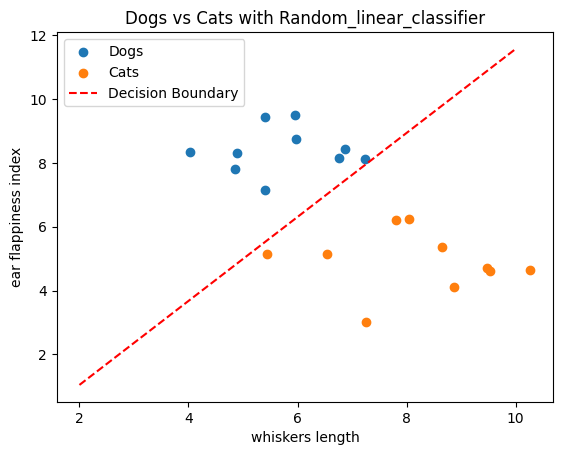

In [ ]:
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index, label='Dogs')
plt.scatter(cats_whisker_length,cats_ear_flappiness_index, label='Cats')
plt.plot(x_vals, y_vals, color= 'red', linestyle='--', label= 'Decision Boundary')
plt.xlabel('whiskers length')
plt.ylabel('ear flappiness index')
plt.title('Dogs vs Cats with Random_linear_classifier')
plt.legend()
plt.show()